Notebook donde estudiamos el algoritmo de Hill Climbing y Simulated Anniling aplicado al problema de la mochila.

Estudiaremos las siguientes variantes de los metodosy finalmente haremos una comparativa de los resultados:

| Problema | Algoritmo |
|------------------|-----------|
0/1 Knapsack clásico | Hill Climbing Simple |
Knapsack Multidimensional | Hill Climbing con Reinicios Aleatorios |
Bounded Knapsack | Simulated Annealing Estándar |
0/1 Knapsack con Penalización | Simulated Annealing con Enfriamiento Adaptativo |

In [1]:
import random
import time
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

# Hill Climbing simple - 0/1 Knapsack clásico

In [2]:
def generate_instance(n, seed=42):
    """
    Genera una instancia aleatoria del 0/1 Knapsack.
    W = 40% del peso total (según enunciado).
    """
    random.seed(seed)
    items   = list(range(1, n + 1))
    values  = [random.randint(1, 30) for _ in range(n)]
    weights = [random.randint(1, 15) for _ in range(n)]
    W       = int(0.4 * sum(weights))
    return items, values, weights, W

# Verificación rápida
items, values, weights, W = generate_instance(10, seed=42)
print(f'items   = {items}')
print(f'values  = {values}')
print(f'weights = {weights}')
print(f'W       = {W}')

items   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
values  = [21, 4, 1, 24, 9, 8, 8, 5, 24, 4]
weights = [11, 12, 15, 9, 2, 10, 7, 1, 1, 2]
W       = 28


In [3]:
def fitness(x, values, weights, W):
    """
    Válida   → devuelve el valor total.
    Inválida → devuelve 0.
    """
    total_weight = sum(weights[i] for i in range(len(x)) if x[i] == 1)
    if total_weight > W:
        return 0
    return sum(values[i] for i in range(len(x)) if x[i] == 1)

def is_valid(x, weights, W):
    """Devuelve True si la solución no excede la capacidad."""
    return sum(weights[i] for i in range(len(x)) if x[i] == 1) <= W

print('Fitness definido ✓')

Fitness definido ✓


In [4]:
def random_initial_solution(n, weights, W, rng):
    """
    Genera una solución binaria aleatoria válida con capacidad libre.
    Cada ítem se incluye con probabilidad 0.3 para no llenar la mochila desde el inicio y permitir que el HC explore añadiendo ítems.
    Se repara quitando ítems al azar si por azar se supera W.
    """
    x = [1 if rng.random() < 0.3 else 0 for _ in range(n)]
    total_w = sum(weights[i] for i in range(n) if x[i] == 1)
    if total_w > W:
        selected = [i for i in range(n) if x[i] == 1]
        rng.shuffle(selected)
        for i in selected:
            if total_w <= W:
                break
            x[i] = 0
            total_w -= weights[i]
    return x

print('Inicialización aleatoria válida definida ✓')

Inicialización aleatoria válida definida ✓


In [5]:
def get_neighbors(x):
    """
    Genera todos los n vecinos invirtiendo un bit a la vez (bit-flip).
    """
    neighbors = []
    for i in range(len(x)):
        neighbor    = x[:]
        neighbor[i] = 1 - neighbor[i]
        neighbors.append(neighbor)
    return neighbors

print('Vecindad definida ✓')

Vecindad definida ✓


In [6]:
def hill_climbing(values, weights, W, seed=None):
    """
    Hill Climbing Simple (Steepest Ascent) para 0/1 Knapsack.
    Inicialización: solución binaria aleatoria válida.

    Retorna:
        x           : solución encontrada (vector binario)
        best_value  : valor total de la solución final (siempre válida)
        iterations  : iteraciones hasta convergencia
        history     : fitness por iteración (para graficar)
        elapsed     : tiempo total de ejecución en segundos
    """
    n   = len(values)
    rng = random.Random(seed)

    # Inicialización aleatoria válida
    x          = random_initial_solution(n, weights, W, rng)
    current_f  = fitness(x, values, weights, W)
    history    = [current_f]
    iterations = 0

    start = time.perf_counter()

    while True:
        neighbors = get_neighbors(x)

        best_neighbor   = None
        best_neighbor_f = current_f

        for neighbor in neighbors:
            f = fitness(neighbor, values, weights, W)
            if f > best_neighbor_f:
                best_neighbor_f = f
                best_neighbor   = neighbor

        # Ningún vecino mejora → óptimo local → detener
        if best_neighbor is None:
            break

        x          = best_neighbor
        current_f  = best_neighbor_f
        history.append(current_f)
        iterations += 1

    elapsed = time.perf_counter() - start

    valid_value = sum(values[i] for i in range(n) if x[i] == 1) if is_valid(x, weights, W) else 0

    return x, valid_value, iterations, history, elapsed

print('Hill Climbing definido ✓')

Hill Climbing definido ✓


In [7]:
SCALES = [10, 50, 100, 250]
SEEDS  = [7, 42, 123]

results = []

for n in SCALES:
    for seed in SEEDS:
        items, values, weights, W = generate_instance(n, seed=seed)
        x, best_value, iterations, history, elapsed = hill_climbing(
            values, weights, W, seed=seed + 1000
        )
        peso_usado = sum(weights[i] for i in range(n) if x[i] == 1)

        results.append({
            'n':           n,
            'seed':        seed,
            'valor':       best_value,
            'peso_usado':  peso_usado,
            'capacidad':   W,
            'iteraciones': iterations,
            'tiempo_s':    round(elapsed, 6),
            'tiempo_ms':   round(elapsed * 1000, 4),
            '_history':    history,
        })

print(f'Experimentos completados: {len(results)} corridas ✓')

Experimentos completados: 12 corridas ✓


In [8]:
hill_climb_1 = pd.DataFrame([{k: v for k, v in r.items() if k != '_history'} for r in results])

hill_climb_1['tiempo_s']  = hill_climb_1['tiempo_s'].map('{:.6f}'.format)
hill_climb_1['tiempo_ms'] = hill_climb_1['tiempo_ms'].map('{:.4f}'.format)

(hill_climb_1)

,n,seed,valor,peso_usado,capacidad,iteraciones,tiempo_s,tiempo_ms
0,10,7,86,22,23,5,0.000162,0.1619
1,10,42,87,26,28,4,0.000131,0.1314
2,10,123,125,23,23,2,0.000086,0.0863
3,50,7,241,154,154,2,0.000803,0.8028
4,50,42,437,150,150,8,0.003090,3.0901
5,50,123,416,189,189,5,0.002270,2.2701
6,100,7,544,313,313,2,0.004428,4.4282
7,100,42,717,334,334,10,0.017276,17.2762
8,100,123,924,291,291,13,0.024766,24.7663
9,250,7,1606,814,814,10,0.141977,141.9774


In [9]:
hill_climb_1.to_csv("hill_climb_1.csv", index=False)

# Hill Climbing con Reinicios Aleatorios - Knapsack Multidimensional 

In [10]:
def generate_instance_2(n, seed=42):
    random.seed(seed)
    items   = list(range(1, n + 1))
    values  = [random.randint(1, 30) for _ in range(n)]
    weights = [random.randint(1, 15) for _ in range(n)]
    volumes = [random.randint(1, 10) for _ in range(n)]
    W       = int(0.4 * sum(weights))
    V       = int(0.4 * sum(volumes))
    return items, values, weights, volumes, W, V

items, values, weights, volumes, W, V = generate_instance_2(10, seed=42)
print(f'items   = {items}')
print(f'values  = {values}')
print(f'weights = {weights}')
print(f'volumes = {volumes}')
print(f'W       = {W}')
print(f'V       = {V}')

items   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
values  = [21, 4, 1, 24, 9, 8, 8, 5, 24, 4]
weights = [11, 12, 15, 9, 2, 10, 7, 1, 1, 2]
volumes = [4, 4, 9, 10, 1, 9, 4, 9, 7, 4]
W       = 28
V       = 24


In [11]:
def fitness_2(x, values, weights, volumes, W, V):
    """
    Válida   → devuelve el valor total.
    Inválida → devuelve 0.  (ambas restricciones deben cumplirse)
    """
    total_weight = sum(weights[i] for i in range(len(x)) if x[i] == 1)
    total_volume = sum(volumes[i] for i in range(len(x)) if x[i] == 1)
    if total_weight > W or total_volume > V:
        return 0
    return sum(values[i] for i in range(len(x)) if x[i] == 1)

def is_valid_2(x, weights, volumes, W, V):
    """Devuelve True si la solución respeta ambas capacidades."""
    return (sum(weights[i] for i in range(len(x)) if x[i] == 1) <= W and
            sum(volumes[i] for i in range(len(x)) if x[i] == 1) <= V)

print('Fitness definido ✓')

Fitness definido ✓


In [12]:
def random_initial_solution_2(n, weights, volumes, W, V, rng):
    """
    Genera una solución binaria aleatoria válida con capacidad libre.
    Cada ítem se incluye con probabilidad 0.3.
    Se repara quitando ítems al azar si alguna restricción es violada.
    """
    x = [1 if rng.random() < 0.3 else 0 for _ in range(n)]
    total_w = sum(weights[i] for i in range(n) if x[i] == 1)
    total_v = sum(volumes[i] for i in range(n) if x[i] == 1)
    if total_w > W or total_v > V:
        selected = [i for i in range(n) if x[i] == 1]
        rng.shuffle(selected)
        for i in selected:
            if total_w <= W and total_v <= V:
                break
            x[i]    = 0
            total_w -= weights[i]
            total_v -= volumes[i]
    return x

print('Inicialización aleatoria válida definida ✓')

Inicialización aleatoria válida definida ✓


In [13]:
def hill_climbing_2(values, weights, volumes, W, V, seed=None):
    """
    Hill Climbing Simple (Steepest Ascent) para Knapsack Multidimensional.
    Inicialización: solución binaria aleatoria válida.
    Vecindad: get_neighbors (bit-flip, reutilizada de P1).

    Retorna:
        x           : solución encontrada (vector binario)
        best_value  : valor total de la solución final (siempre válida)
        iterations  : iteraciones hasta convergencia
        history     : fitness por iteración
        elapsed     : tiempo total de ejecución en segundos
    """
    n   = len(values)
    rng = random.Random(seed)

    x          = random_initial_solution_2(n, weights, volumes, W, V, rng)
    current_f  = fitness_2(x, values, weights, volumes, W, V)
    history    = [current_f]
    iterations = 0

    start = time.perf_counter()

    while True:
        neighbors = get_neighbors(x)

        best_neighbor   = None
        best_neighbor_f = current_f

        for neighbor in neighbors:
            f = fitness_2(neighbor, values, weights, volumes, W, V)
            if f > best_neighbor_f:
                best_neighbor_f = f
                best_neighbor   = neighbor

        if best_neighbor is None:
            break

        x          = best_neighbor
        current_f  = best_neighbor_f
        history.append(current_f)
        iterations += 1

    elapsed = time.perf_counter() - start

    valid_value = (sum(values[i] for i in range(n) if x[i] == 1)
                   if is_valid_2(x, weights, volumes, W, V) else 0)

    return x, valid_value, iterations, history, elapsed

print('Hill Climbing MDK definido ✓')

Hill Climbing MDK definido ✓


In [14]:
def hc_random_restart_2(values, weights, volumes, W, V, R=10, seed=42):
    """
    Hill Climbing con R Reinicios Aleatorios para Knapsack Multidimensional.
    Cada reinicio usa semilla aislada (seed + r*7).

    Retorna:
        best_sol   : mejor solución encontrada entre todos los reinicios
        best_fit   : valor de esa solución
        best_iters : iteraciones del reinicio que encontró la mejor solución
        elapsed    : tiempo total de ejecución en segundos
    """
    best_sol   = None
    best_fit   = -1
    best_iters = 0
    t0         = time.perf_counter()

    for r in range(R):
        seed_r = seed + r * 7
        sol, fit, iters, _, _ = hill_climbing_2(values, weights, volumes, W, V, seed=seed_r)
        if fit > best_fit:
            best_fit   = fit
            best_sol   = sol
            best_iters = iters

    elapsed = time.perf_counter() - t0
    return best_sol, best_fit, best_iters, elapsed

print('HC con Reinicios Aleatorios MDK definido ✓')

HC con Reinicios Aleatorios MDK definido ✓


In [15]:
SCALES_2  = [10, 50, 100, 250]
SEEDS_2   = [7, 42, 123]
R_VALUES  = [5, 15, 30]

results_2 = []

for n in SCALES_2:
    for seed in SEEDS_2:
        for R in R_VALUES:
            items, values, weights, volumes, W, V = generate_instance_2(n, seed=seed)
            best_sol, best_fit, best_iters, elapsed = hc_random_restart_2(
                values, weights, volumes, W, V, R=R, seed=seed
            )
            peso_usado = sum(weights[i] * best_sol[i] for i in range(n))
            vol_usado  = sum(volumes[i] * best_sol[i] for i in range(n))

            results_2.append({
                'n':           n,
                'seed':        seed,
                'R':           R,
                'valor':       best_fit,
                'peso_usado':  peso_usado,
                'cap_W':       W,
                'vol_usado':   vol_usado,
                'cap_V':       V,
                'iteraciones': best_iters,
                'tiempo_s':    round(elapsed, 6),
                'tiempo_ms':   round(elapsed * 1000, 4),
            })

print(f'Experimentos completados: {len(results_2)} corridas ✓')

Experimentos completados: 36 corridas ✓


In [16]:
hill_climb_2 = pd.DataFrame(results_2)

hill_climb_2['tiempo_s']  = hill_climb_2['tiempo_s'].map('{:.6f}'.format)
hill_climb_2['tiempo_ms'] = hill_climb_2['tiempo_ms'].map('{:.4f}'.format)

(hill_climb_2)

,n,seed,R,valor,peso_usado,cap_W,vol_usado,cap_V,iteraciones,tiempo_s,tiempo_ms
0,10,7,5,73,22,23,13,20,2,0.001326,1.3257
1,10,7,15,83,21,23,16,20,3,0.003151,3.1505
2,10,7,30,83,21,23,16,20,3,0.004202,4.2017
3,10,42,5,61,24,28,22,24,2,0.000499,0.4988
4,10,42,15,78,23,28,22,24,4,0.001728,1.7278
5,10,42,30,78,23,28,22,24,4,0.003682,3.6825
6,10,123,5,98,13,23,22,22,3,0.000581,0.5809
7,10,123,15,98,13,23,22,22,3,0.002193,2.1929
8,10,123,30,98,13,23,22,22,3,0.003363,3.3635
9,50,7,5,339,148,154,111,111,5,0.010862,10.8621


In [17]:
hill_climb_2.to_csv("hill_climb_2.csv", index=False)

# Simulated Annealing Estándar - Bounded Knapsack 

In [18]:
def generate_instance_3(n, seed=42):
    random.seed(seed)
    items   = list(range(1, n + 1))
    values  = [random.randint(1, 30) for _ in range(n)]
    weights = [random.randint(1, 15) for _ in range(n)]
    counts  = [random.randint(1,  5) for _ in range(n)]
    W       = int(0.5 * sum(w * c for w, c in zip(weights, counts)))
    return items, values, weights, counts, W

items, values, weights, counts, W = generate_instance_3(10, seed=42)
print(f'items   = {items}')
print(f'values  = {values}')
print(f'weights = {weights}')
print(f'counts  = {counts}')
print(f'W       = {W}')

items   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
values  = [21, 4, 1, 24, 9, 8, 8, 5, 24, 4]
weights = [11, 12, 15, 9, 2, 10, 7, 1, 1, 2]
counts  = [2, 2, 5, 5, 1, 5, 2, 5, 4, 2]
W       = 122


In [19]:
def fitness_3(x, values, weights, W):
    """
    Válida   → devuelve el valor total  sum(v_i * x_i).
    Inválida → devuelve 0.
    x_i ∈ {0, …, c_i}  (vector entero)
    """
    total_weight = sum(weights[i] * x[i] for i in range(len(x)))
    if total_weight > W:
        return 0
    return sum(values[i] * x[i] for i in range(len(x)))

def is_valid_3(x, weights, W):
    """Devuelve True si la solución no excede la capacidad."""
    return sum(weights[i] * x[i] for i in range(len(x))) <= W

print('Fitness definido ✓')

Fitness definido ✓


In [20]:
def random_solution_3(counts, rng):
    """
    Genera un vector solución entero aleatorio dentro de [0, c_i].
    SA no requiere reparación: Metropolis permite explorar infactibles.
    """
    return [rng.randint(0, c) for c in counts]

def get_neighbour_3(x, counts, rng):
    """
    Genera un vecino aplicando ±1 a un ítem elegido aleatoriamente,
    respetando el rango [0, c_i].
    """
    nb    = x[:]
    i     = rng.randint(0, len(x) - 1)
    delta = rng.choice([-1, +1])
    nb[i] = max(0, min(counts[i], nb[i] + delta))
    return nb

print('Solución inicial y vecindad definidas ✓')

Solución inicial y vecindad definidas ✓


In [21]:
def simulated_annealing_3(values, weights, counts, W,
                          T0=100.0, alpha=0.99, T_min=0.01,
                          iter_per_T=50, seed=42):
    """
    Simulated Annealing Estándar con enfriamiento geométrico T(k) = T0·αᵏ
    aplicado al Bounded Knapsack.

    Retorna:
        best_x    : mejor solución encontrada (vector entero)
        best_f    : valor de la mejor solución
        niveles_T : niveles de temperatura completados hasta convergencia
        elapsed   : tiempo total de ejecución en segundos
    """
    rng = random.Random(seed)

    x      = random_solution_3(counts, rng)
    fx     = fitness_3(x, values, weights, W)
    best_x = x[:]
    best_f = fx

    T       = T0
    niveles = 0

    start = time.perf_counter()

    while T > T_min:
        for _ in range(iter_per_T):
            nb    = get_neighbour_3(x, counts, rng)
            nb_f  = fitness_3(nb, values, weights, W)
            delta = nb_f - fx
            if delta > 0 or rng.random() < math.exp(delta / T):
                x  = nb
                fx = nb_f
            if fx > best_f:
                best_f = fx
                best_x = x[:]
        T       *= alpha
        niveles += 1

    elapsed = time.perf_counter() - start
    return best_x, best_f, niveles, elapsed

print('Simulated Annealing Estándar definido ✓')

Simulated Annealing Estándar definido ✓


In [22]:
SCALES_3 = [10, 50, 100, 250]
SEEDS_3  = [7, 42, 123]
ALPHAS   = [0.90, 0.95, 0.99]

results_3 = []

for n in SCALES_3:
    for seed in SEEDS_3:
        for alpha in ALPHAS:
            items, values, weights, counts, W = generate_instance_3(n, seed=seed)
            best_x, best_f, niveles, elapsed = simulated_annealing_3(
                values, weights, counts, W,
                T0=100.0, alpha=alpha, T_min=0.01, iter_per_T=50, seed=seed
            )
            peso_usado = sum(weights[i] * best_x[i] for i in range(n))

            results_3.append({
                'n':          n,
                'seed':       seed,
                'alpha':      alpha,
                'valor':      best_f,
                'peso_usado': peso_usado,
                'capacidad':  W,
                'niveles_T':  niveles,
                'tiempo_s':   round(elapsed, 6),
                'tiempo_ms':  round(elapsed * 1000, 4),
            })

print(f'Experimentos completados: {len(results_3)} corridas ✓')

Experimentos completados: 36 corridas ✓


In [23]:
sa_3 = pd.DataFrame(results_3)

sa_3['tiempo_s']  = sa_3['tiempo_s'].map('{:.6f}'.format)
sa_3['tiempo_ms'] = sa_3['tiempo_ms'].map('{:.4f}'.format)

(sa_3)

,n,seed,alpha,valor,peso_usado,capacidad,niveles_T,tiempo_s,tiempo_ms
0,10,7,0.90,203,97,97,88,0.024662,24.6615
1,10,7,0.95,211,94,97,180,0.054785,54.7851
2,10,7,0.99,214,95,97,917,0.248167,248.1668
3,10,42,0.90,332,122,122,88,0.024296,24.2963
4,10,42,0.95,332,116,122,180,0.047930,47.9300
5,10,42,0.99,332,119,122,917,0.297058,297.0577
6,10,123,0.90,407,92,92,88,0.022997,22.9969
7,10,123,0.95,407,92,92,180,0.054294,54.2942
8,10,123,0.99,407,92,92,917,0.245407,245.4075
9,50,7,0.90,1381,556,559,88,0.097326,97.3258


In [24]:
sa_3.to_csv("sa_3.csv", index=False)

# Simulated Annealing Adaptativo - 0/1 Knapsack con Penalización

In [25]:
def generate_instance_4(n, seed=42):
    random.seed(seed)
    items   = list(range(1, n + 1))
    values  = [random.randint(1, 50) for _ in range(n)]
    weights = [random.randint(1, 20) for _ in range(n)]
    W       = int(0.4 * sum(weights))
    return items, values, weights, W

items, values, weights, W = generate_instance_4(10, seed=42)
print(f'items   = {items}')
print(f'values  = {values}')
print(f'weights = {weights}')
print(f'W       = {W}')

items   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
values  = [41, 8, 2, 48, 18, 16, 15, 9, 48, 7]
weights = [18, 3, 19, 14, 2, 1, 3, 7, 8, 17]
W       = 36


In [26]:
def fitness_4(x, values, weights, W, lam):
    """
    Fitness con penalización proporcional al exceso de peso.
    f(x) = valor_total - λ · exceso
    Permite explorar regiones infactibles durante la búsqueda.
    """
    total_value  = sum(values[i]  for i in range(len(x)) if x[i] == 1)
    total_weight = sum(weights[i] for i in range(len(x)) if x[i] == 1)
    excess       = max(0, total_weight - W)
    return total_value - lam * excess

def is_valid_4(x, weights, W):
    """Devuelve True si la solución no excede la capacidad."""
    return sum(weights[i] for i in range(len(x)) if x[i] == 1) <= W

print('Fitness con penalización definido ✓')

Fitness con penalización definido ✓


In [27]:
def flip_bits_4(x, n_bits, rng):
    """
    Genera un vecino invirtiendo n_bits bits elegidos aleatoriamente.
    n_bits ∈ {1, 2} — amplía la exploración respecto al flip simple.
    """
    x_new   = x[:]
    indices = rng.sample(range(len(x)), n_bits)
    for i in indices:
        x_new[i] = 1 - x_new[i]
    return x_new

print('Vecindad (flip 1-2 bits) definida ✓')

Vecindad (flip 1-2 bits) definida ✓


In [28]:
def simulated_annealing_4(values, weights, W, lam,
                          T0=200.0, beta=0.0005, T_min=0.001,
                          max_iter=50000, seed=42):
    """
    Simulated Annealing con enfriamiento adaptativo de Lundy & Mees:
        T(k+1) = T(k) / (1 + β·T(k))
    aplicado al 0/1 Knapsack con función de penalización.

    Se rastrea la mejor solución FACTIBLE encontrada por separado.

    Retorna:
        best_x      : mejor solución factible encontrada (vector binario)
        best_f      : valor total de esa solución
        iteraciones : iteraciones ejecutadas hasta T < T_min o max_iter
        elapsed     : tiempo total de ejecución en segundos
    """
    rng = random.Random(seed)
    n   = len(values)

    x      = [rng.randint(0, 1) for _ in range(n)]
    fx     = fitness_4(x, values, weights, W, lam)
    best_x = x[:]
    best_f = (sum(values[i] for i in range(n) if x[i] == 1)
              if is_valid_4(x, weights, W) else 0)

    T           = T0
    iteraciones = 0

    start = time.perf_counter()

    for _ in range(max_iter):
        if T < T_min:
            break
        n_bits = rng.choice([1, 2])
        nb     = flip_bits_4(x, n_bits, rng)
        nb_f   = fitness_4(nb, values, weights, W, lam)
        delta  = nb_f - fx
        if delta > 0 or rng.random() < math.exp(delta / T):
            x  = nb
            fx = nb_f
            if is_valid_4(x, weights, W):
                val = sum(values[i] for i in range(n) if x[i] == 1)
                if val > best_f:
                    best_f = val
                    best_x = x[:]
        T            = T / (1 + beta * T)
        iteraciones += 1

    elapsed = time.perf_counter() - start
    return best_x, best_f, iteraciones, elapsed

print('Simulated Annealing Adaptativo (Lundy & Mees) definido ✓')

Simulated Annealing Adaptativo (Lundy & Mees) definido ✓


In [29]:
SCALES_4 = [10, 50, 100, 250]
SEEDS_4  = [7, 42, 123]
LAMBDAS  = [1, 5, 10]

results_4 = []

for n in SCALES_4:
    for seed in SEEDS_4:
        for lam in LAMBDAS:
            items, values, weights, W = generate_instance_4(n, seed=seed)
            best_x, best_f, iteraciones, elapsed = simulated_annealing_4(
                values, weights, W, lam=lam,
                T0=100.0, beta=0.001, T_min=0.001, max_iter=50000, seed=seed
            )
            peso_usado = sum(weights[i] for i in range(n) if best_x[i] == 1)

            results_4.append({
                'n':           n,
                'seed':        seed,
                'lambda':      lam,
                'valor':       best_f,
                'peso_usado':  peso_usado,
                'capacidad':   W,
                'iteraciones': iteraciones,
                'tiempo_s':    round(elapsed, 6),
                'tiempo_ms':   round(elapsed * 1000, 4),
            })

print(f'Experimentos completados: {len(results_4)} corridas ✓')

Experimentos completados: 36 corridas ✓


In [30]:
sa_4 = pd.DataFrame(results_4)

sa_4['tiempo_s']  = sa_4['tiempo_s'].map('{:.6f}'.format)
sa_4['tiempo_ms'] = sa_4['tiempo_ms'].map('{:.4f}'.format)

(sa_4)

,n,seed,lambda,valor,peso_usado,capacidad,iteraciones,tiempo_s,tiempo_ms
0,10,7,1,162,28,29,50000,0.411287,411.2869
1,10,7,5,162,28,29,50000,0.413479,413.4788
2,10,7,10,162,28,29,50000,0.394897,394.8968
3,10,42,1,97,35,36,50000,0.393392,393.3916
4,10,42,5,154,35,36,50000,0.409679,409.6794
5,10,42,10,154,35,36,50000,0.394945,394.9450
6,10,123,1,155,32,40,50000,0.401175,401.1754
7,10,123,5,155,38,40,50000,0.377965,377.9651
8,10,123,10,155,38,40,50000,0.375084,375.0841
9,50,7,1,0,244,242,50000,0.767539,767.5392


In [31]:
sa_4.to_csv("sa_4.csv", index=False)

# Graficos

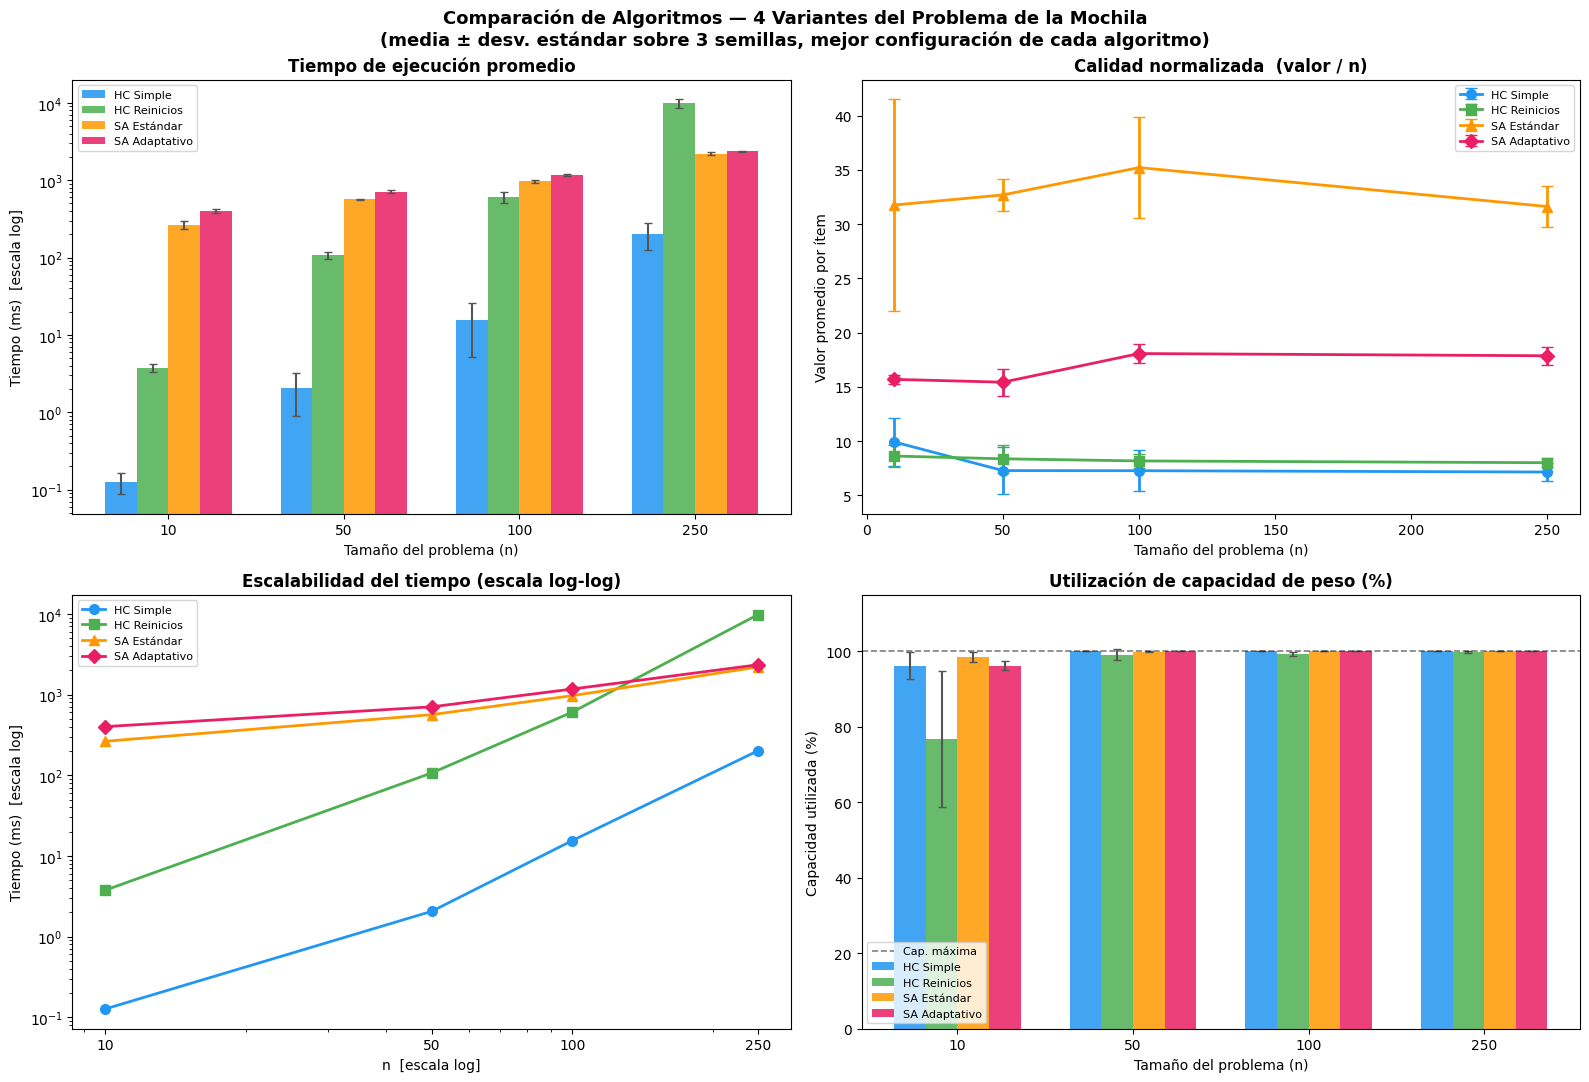

Figura guardada como comparacion_algoritmos.png ✓


In [32]:
# ── Reconstruir DataFrames numéricos desde las listas originales ──────────────
_df1 = pd.DataFrame([{k: v for k, v in r.items() if k != '_history'} for r in results])
_df2 = pd.DataFrame(results_2)
_df3 = pd.DataFrame(results_3)
_df4 = pd.DataFrame(results_4)

# Mejor configuración por algoritmo (parámetro más exigente de cada uno)
_d1 = _df1.copy()                           # HC Simple: sin hiperparámetros
_d2 = _df2[_df2['R'] == 30].copy()          # HC Reinicios: R=30
_d3 = _df3[_df3['alpha'] == 0.99].copy()    # SA Estándar: alpha=0.99
_d4 = _df4[_df4['lambda'] == 5].copy()      # SA Adaptativo: lambda=5

ESCALAS      = [10, 50, 100, 250]
COLORES      = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
ALGS_SHORT   = ['HC Simple', 'HC Reinicios', 'SA Estándar', 'SA Adaptativo']
MARKERS      = ['o', 's', '^', 'D']

# ── Funciones auxiliares ──────────────────────────────────────────────────────
def stats_by_n(df, col):
    """Devuelve (medias, desv. estándar) agrupadas por escala n."""
    mu = np.array([df[df['n'] == n][col].mean() for n in ESCALAS])
    sd = np.array([df[df['n'] == n][col].std(ddof=1) for n in ESCALAS])
    return mu, sd

def util_stats(df, weight_col='peso_usado', cap_col='capacidad'):
    """Calcula % de utilización de capacidad (media ± std) por escala."""
    mu, sd = [], []
    for n in ESCALAS:
        sub = df[df['n'] == n]
        pct = (sub[weight_col] / sub[cap_col]) * 100
        mu.append(pct.mean()); sd.append(pct.std(ddof=1))
    return np.array(mu), np.array(sd)

# ── Extraer métricas ──────────────────────────────────────────────────────────
# Tiempo en ms
t_mu, t_sd = [], []
for d in [_d1, _d2, _d3, _d4]:
    mu, sd = stats_by_n(d, 'tiempo_s')
    t_mu.append(mu * 1000); t_sd.append(sd * 1000)

# Calidad normalizada: valor / n  (comparable entre variantes con distintas escalas de valor)
vn_mu, vn_sd = [], []
for d in [_d1, _d2, _d3, _d4]:
    mu, sd = stats_by_n(d, 'valor')
    vn_mu.append(mu / np.array(ESCALAS))
    vn_sd.append(sd / np.array(ESCALAS))

# Utilización de capacidad de peso (%)
u_mu, u_sd = [], []
for d, wc, cc in [(_d1,'peso_usado','capacidad'), (_d2,'peso_usado','cap_W'),
                   (_d3,'peso_usado','capacidad'), (_d4,'peso_usado','capacidad')]:
    mu, sd = util_stats(d, wc, cc)
    u_mu.append(mu); u_sd.append(sd)

# ── FIGURA 2×2 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Comparación de Algoritmos — 4 Variantes del Problema de la Mochila\n'
    '(media ± desv. estándar sobre 3 semillas, mejor configuración de cada algoritmo)',
    fontsize=13, fontweight='bold'
)

x    = np.arange(len(ESCALAS))
w    = 0.18
offs = np.array([-1.5, -0.5, 0.5, 1.5]) * w
ekw  = dict(linewidth=1.2, ecolor='#555555', capsize=3)

# ── Gráfico 1: Tiempo de ejecución (barras agrupadas, eje log) ────────────────
ax = axes[0, 0]
for mu, sd, col, lbl, i in zip(t_mu, t_sd, COLORES, ALGS_SHORT, range(4)):
    ax.bar(x + offs[i], mu, w, label=lbl, color=col, alpha=0.85, yerr=sd, **ekw)
ax.set_yscale('log')
ax.set_title('Tiempo de ejecución promedio', fontweight='bold')
ax.set_xlabel('Tamaño del problema (n)')
ax.set_ylabel('Tiempo (ms)  [escala log]')
ax.set_xticks(x); ax.set_xticklabels(ESCALAS)
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.legend(fontsize=8)

# ── Gráfico 2: Calidad normalizada valor/n (líneas con error bars) ────────────
ax = axes[0, 1]
for mu, sd, col, lbl, mk in zip(vn_mu, vn_sd, COLORES, ALGS_SHORT, MARKERS):
    ax.errorbar(ESCALAS, mu, yerr=sd, marker=mk, color=col,
                linewidth=2, capsize=4, markersize=7, label=lbl)
ax.set_title('Calidad normalizada  (valor / n)', fontweight='bold')
ax.set_xlabel('Tamaño del problema (n)')
ax.set_ylabel('Valor promedio por ítem')
ax.legend(fontsize=8)

# ── Gráfico 3: Escalabilidad del tiempo (log-log, sin error bars) ─────────────
ax = axes[1, 0]
for mu, col, lbl, mk in zip(t_mu, COLORES, ALGS_SHORT, MARKERS):
    ax.plot(ESCALAS, mu, marker=mk, color=col, linewidth=2, markersize=7, label=lbl)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Escalabilidad del tiempo (escala log-log)', fontweight='bold')
ax.set_xlabel('n  [escala log]')
ax.set_ylabel('Tiempo (ms)  [escala log]')
ax.set_xticks(ESCALAS)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.legend(fontsize=8)

# ── Gráfico 4: Utilización de capacidad (barras agrupadas con error bars) ──────
ax = axes[1, 1]
for mu, sd, col, lbl, i in zip(u_mu, u_sd, COLORES, ALGS_SHORT, range(4)):
    ax.bar(x + offs[i], mu, w, label=lbl, color=col, alpha=0.85, yerr=sd, **ekw)
ax.axhline(100, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='Cap. máxima')
ax.set_title('Utilización de capacidad de peso (%)', fontweight='bold')
ax.set_xlabel('Tamaño del problema (n)')
ax.set_ylabel('Capacidad utilizada (%)')
ax.set_xticks(x); ax.set_xticklabels(ESCALAS)
ax.set_ylim(0, 115)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('comparacion_algoritmos.png', dpi=450, bbox_inches='tight')
plt.show()
print('Figura guardada como comparacion_algoritmos.png ✓')

# Panel Interactivo

Selecciona el algoritmo y su hiperparámetro. El tablero muestra la **figura comparativa global** de los 4 algoritmos (sección _Graficos_) y, debajo, la **tabla de resultados** del algoritmo elegido agregada sobre el barrido n=[10, 50, 100, 250] × semillas [7, 42, 123] en media ± desviación estándar.